TP: Principal  Component Analysis

In [2]:
import numpy as np
from scipy.stats import chi2, multivariate_normal
import sklearn
import matplotlib.pyplot as plt

Question 1:

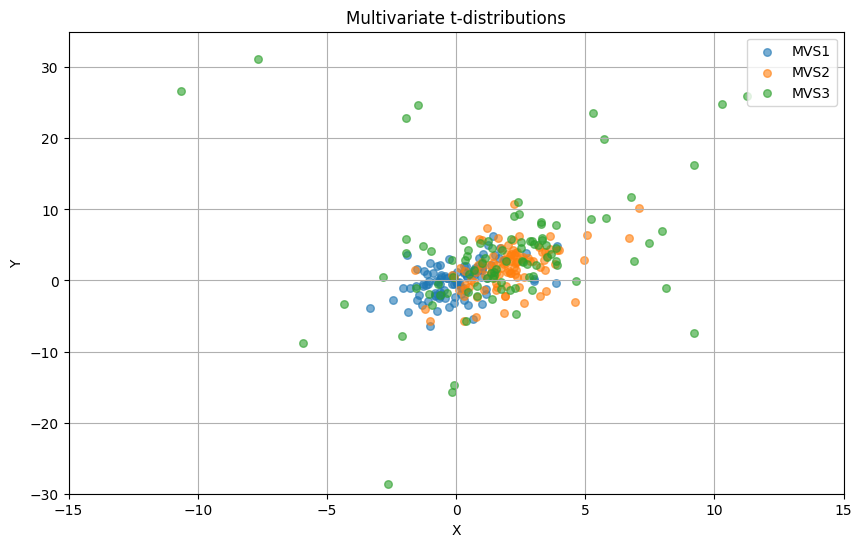

In [3]:
def mrt(mu,sigma,nu,n):
    d=len(mu)
    mu = np.array(mu)
    Z=multivariate_normal.rvs(mean=np.zeros(d),cov=sigma,size=n) #nlines d=2 columns
    W=chi2.rvs(df=nu,size=n)
    scale=np.sqrt(nu / W)[:, np.newaxis] #vector of size n become size n x 1
    X = mu + scale*Z
    return X

MVS1=mrt(mu=[0,0],sigma=np.array([[1,1],[1,4]]),nu=5,n=100)
MVS2=mrt(mu=[2,2],sigma=np.array([[1,1],[1,4]]),nu=3,n=100)
MVS3=mrt(mu=[2,2],sigma=np.array([[4,4],[4,16]]),nu=1,n=100)
plt.figure(figsize=(10, 6))
plt.scatter(MVS1[:, 0], MVS1[:, 1], alpha=0.6, label='MVS1', s=30)
plt.scatter(MVS2[:, 0], MVS2[:, 1], alpha=0.6, label='MVS2', s=30)
plt.scatter(MVS3[:, 0], MVS3[:, 1], alpha=0.6, label='MVS3', s=30)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Multivariate t-distributions')
plt.grid(True)
plt.xlim(-15, 15)
plt.ylim(-30, 35)
plt.show()

Question 2:

In [4]:
from sklearn.preprocessing import StandardScaler

t5=mrt(mu=[0,0,0],sigma=[[1,1,1],[1,4,4],[1,4,9]],nu=5,n=1000) #size 1000*3
P=np.array([[0,1,1],[-1,-1,1],[-1,-1,1],[0,-1,1],[1,0,2]])
proj_t5=t5 @ P.T #size 1000*5
proj_t5_scaled=StandardScaler().fit_transform(proj_t5)
proj_t5_scaled_shifted= proj_t5_scaled + np.array([1,2,3,4,5])
noise=multivariate_normal.rvs(mean=np.zeros(5),cov=0.025*np.eye(5),size=1000)
Final_dataset=proj_t5_scaled_shifted + noise
print(Final_dataset.shape)

(1000, 5)


Question 3:

Singular values: [60.35370222 36.38539404 10.15813737  5.23018345  4.96528747]
Explained variance: [3.64621559 1.32522212 0.10329105 0.0273822  0.02467876]
full principal components: [[ 0.35183797  0.46567398  0.46495036  0.50882209  0.42927733]
 [ 0.63947452 -0.39641134 -0.39867596 -0.141166    0.50503468]
 [-0.46866897 -0.3685962  -0.28983908  0.69809833  0.27044088]
 [ 0.03737337 -0.69051687  0.72121216 -0.02916314 -0.02814645]
 [-0.49622073  0.11545165  0.14396172 -0.48268051  0.6976607 ]]


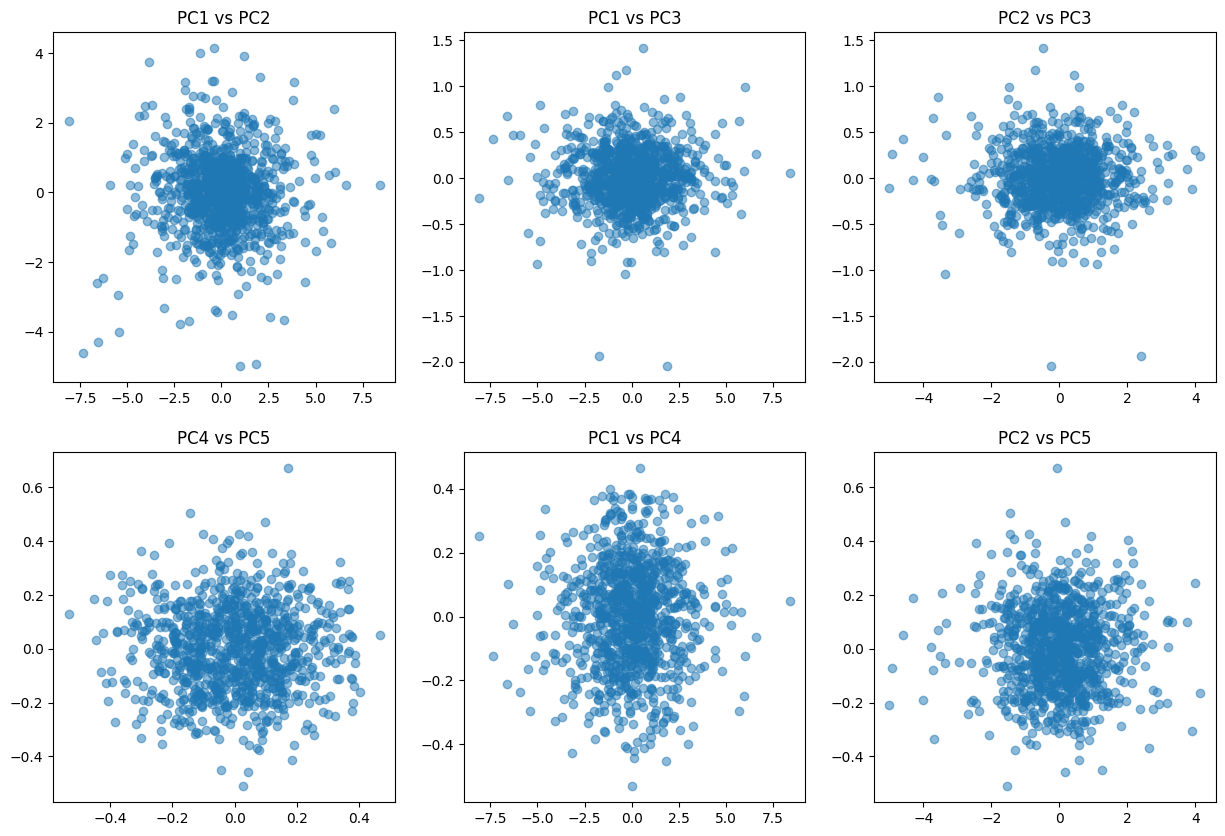

In [5]:
from sklearn.decomposition import PCA

pca=PCA()
X_pca=pca.fit_transform(Final_dataset) #size 1000*5

print("Singular values:", pca.singular_values_)
print("Explained variance:", pca.explained_variance_)
print("full principal components:", pca.components_)

fig, ax = plt.subplots(2, 3,figsize=(15, 10))
# PC1 vs PC2
ax[0,0].scatter(X_pca[:,0], X_pca[:,1], alpha=0.5); ax[0,0].set_title("PC1 vs PC2")
# PC1 vs PC3
ax[0,1].scatter(X_pca[:,0], X_pca[:,2], alpha=0.5); ax[0,1].set_title("PC1 vs PC3")
# PC2 vs PC3
ax[0,2].scatter(X_pca[:,1], X_pca[:,2], alpha=0.5); ax[0,2].set_title("PC2 vs PC3")
# PC4 vs PC5
ax[1,0].scatter(X_pca[:,3], X_pca[:,4], alpha=0.5); ax[1,0].set_title("PC4 vs PC5")
# PC1 vs PC4
ax[1,1].scatter(X_pca[:,0], X_pca[:,3], alpha=0.5); ax[1,1].set_title("PC1 vs PC4")
# PC2 vs PC5
ax[1,2].scatter(X_pca[:,1], X_pca[:,4], alpha=0.5); ax[1,2].set_title("PC2 vs PC5")
plt.show()


"The first three singular values are large compared to the others. This indicates that the data primarily lies in a 3-dimensional subspace, which is consistent with the generation process (rank 3)
The scales of PC1, PC2, and PC3 are significantly larger (ranges > 4) than those of PC4 and PC5.

The last two components (PC4, PC5) have a very small scale (range < 1) and show a spherical shape, representing the isotropic noise added to the data.

PC1, PC2, PC3: We should see elongated structures (ellipsoidal clouds) because the variance is significant.  
PC4, PC5: We should see a spherical cloud (“ball”). Why? Because in these directions, there is only Gaussian noise \(0.025 \times I_5\). The variance is the same in all directions orthogonal to the signal subspace.

Question 4:

In [6]:
X_centered = Final_dataset - np.mean(Final_dataset, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
U, S, Vt = np.linalg.svd(cov_matrix)
print("Singular values from SVD:", np.sqrt(S * (1000-1)))
print("Explained variance from SVD:", S)
print("Full principal components from SVD:", Vt)

Singular values from SVD: [60.35370222 36.38539404 10.15813737  5.23018345  4.96528747]
Explained variance from SVD: [3.64621559 1.32522212 0.10329105 0.0273822  0.02467876]
Full principal components from SVD: [[-0.35183797 -0.46567398 -0.46495036 -0.50882209 -0.42927733]
 [ 0.63947452 -0.39641134 -0.39867596 -0.141166    0.50503468]
 [-0.46866897 -0.3685962  -0.28983908  0.69809833  0.27044088]
 [-0.03737337  0.69051687 -0.72121216  0.02916314  0.02814645]
 [-0.49622073  0.11545165  0.14396172 -0.48268051  0.6976607 ]]


Yes they coincide since ACP is based on the SVD of the centered data matrix or a diagonalization of the covariance matrix.

Question 5:

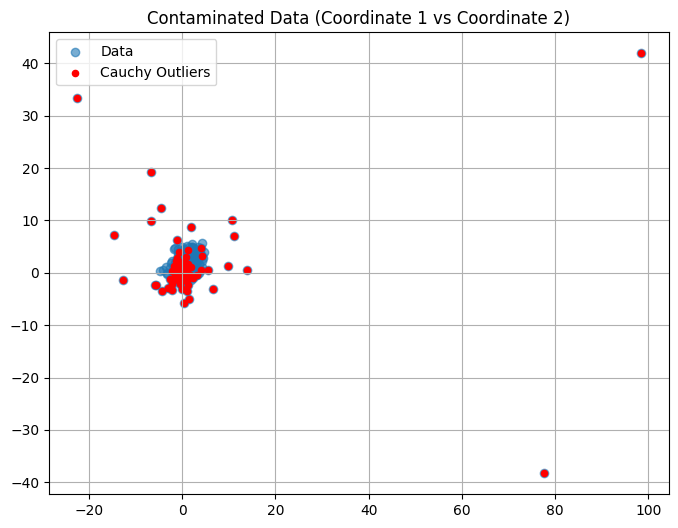

In [8]:

X_contaminated = Final_dataset.copy()
n_outliers = 100 # 10% of 1000


cauchy_noise = mrt(mu=np.zeros(5), sigma=np.eye(5), nu=1, n=n_outliers)

# Replace
X_contaminated[-n_outliers:] = cauchy_noise


plt.figure(figsize=(8, 6))
plt.scatter(X_contaminated[:, 0], X_contaminated[:, 1], alpha=0.6, label='Data')


plt.scatter(X_contaminated[-n_outliers:, 0], X_contaminated[-n_outliers:, 1], color='red', s=20, label='Cauchy Outliers')

plt.title("Contaminated Data (Coordinate 1 vs Coordinate 2)")
plt.legend()
plt.grid(True)
plt.show()

The presence of a few extreme values makes the raw visualization unreadable and suggests that the empirical variance is entirely controlled by these outliers.

Question 6:

In [9]:
pca_dirty = PCA()
pca_dirty.fit(X_contaminated)

print("--- ACP CLASSIQUE (Données Contaminées) ---")
print("Explained variance ratio:", pca_dirty.explained_variance_ratio_)
print("Singular Values:", pca_dirty.singular_values_)
print("Principal Components (Vectors):\n", pca_dirty.components_)

--- ACP CLASSIQUE (Données Contaminées) ---
Explained variance ratio: [0.56751386 0.18861769 0.12432568 0.06688226 0.05266051]
Singular Values: [156.74375585  90.36353754  73.36390307  53.80931842  47.74682829]
Principal Components (Vectors):
 [[ 0.81250144 -0.00763692  0.33746903  0.27341272  0.38877142]
 [ 0.28786472  0.74362942 -0.50548428  0.18095083 -0.27548433]
 [-0.49479668  0.51068342  0.38880006  0.41066122  0.41781642]
 [-0.11014752 -0.40059865 -0.59246895  0.62197051  0.2992014 ]
 [ 0.00436719  0.16025019 -0.35835087 -0.58052763  0.71335344]]


No they will not coincide.
The first component (PC1) will likely align in the direction of the most extreme outlier (the farthest Cauchy point).

The rank-3 structure (the signal) will be drowned out. You may see 99% of the variance explained on the first axis, solely because of an aberrant point.


In [11]:
from sklearn.covariance import MinCovDet
mcd = MinCovDet(support_fraction=0.75, random_state=42)
mcd.fit(X_contaminated)

# Moyenne robuste et Covariance robuste
robust_mean = mcd.location_
robust_cov = mcd.covariance_

print("\n ESTIMATION (MCD)")
print("Estimated mean MCD :", robust_mean)
print("True mean (Shift) :", np.array([1, 2, 3, 4, 5]))


 ESTIMATION (MCD)
Estimated mean MCD : [1.03138103 1.98865485 2.99559535 3.99241798 5.02357851]
True mean (Shift) : [1 2 3 4 5]


Yes the mean looks reasonable, close to the true shift [1,2,3,4,5].

In [12]:
U_rob, S_rob, Vt_rob = np.linalg.svd(robust_cov)

print("\nACP (Via MCD)")
print("eigenvalues (SVD MCD) :", S_rob)

print("Principal Components (Axes) :\n", Vt_rob)


ACP (Via MCD)
eigenvalues (SVD MCD) : [2.92034872 1.03113805 0.08730413 0.02795634 0.02381684]
Principal Components (Axes) :
 [[-0.32240224 -0.4821487  -0.48247176 -0.51316166 -0.40923774]
 [ 0.64536078 -0.37678441 -0.39150132 -0.10350127  0.52683696]
 [-0.49580151 -0.37207115 -0.26254176  0.68418048  0.28055803]
 [-0.08761647  0.6938352  -0.71051789  0.00944042  0.07740331]
 [-0.47546869  0.07564324  0.20045915 -0.50770123  0.6857574 ]]


 Coincidence? Yes, or very close. Robust PCA recovers the principal directions of the original signal (Q3/Q4) and ignores the 10% of Cauchy noise.

The first 3 eigenvalues will be large, and the last 2 very small (the Gaussian noise floor), thus recovering rank 3.